## Model fitting + Cluster analysis

In [1]:
from utils.ml import prepare_data_pipeline, data_dir
from pyspark.sql import functions as F
from pyspark.sql import SparkSession
from pyspark.ml.clustering import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

spark = SparkSession.builder.appName("ML").master("local[*]").getOrCreate()
spark.conf.set("spark.sql.ansi.enabled", False)
df_raw = spark.read.csv(data_dir, inferSchema=True, header=True, sep=";")
df, pipeline = prepare_data_pipeline(df_raw)

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/04/19 11:48:51 WARN Utils: Your hostname, DESKTOP-UQF5BSK, resolves to a loopback address: 127.0.1.1; using 172.24.225.163 instead (on interface eth0)
26/04/19 11:48:51 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/04/19 11:48:53 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


+----+-----+---+-----+-------+----------+-------------+------+--------+-----------------+-----+-------+----+-----+------------+------------+
|year|month|day|order|country|session ID|main_category|colour|location|model photography|price|price 2|page|index|model_letter|model_number|
+----+-----+---+-----+-------+----------+-------------+------+--------+-----------------+-----+-------+----+-----+------------+------------+
|2008|    4|  1|    1|      0|         1|            1|     1|       5|                1|   28|      2|   1|    0|           A|          13|
|2008|    4|  1|    2|      0|         1|            1|     1|       6|                1|   33|      2|   1|    1|           A|          16|
|2008|    4|  1|    3|      0|         1|            2|    10|       2|                1|   52|      1|   1|    2|           B|           4|
|2008|    4|  1|    4|      0|         1|            2|     6|       6|                2|   38|      2|   1|    3|           B|          17|
|2008|    4| 

### Fitting on the best observed setup

In [2]:
stages = pipeline.getStages()
model = KMeans(featuresCol="reduced", predictionCol="pred", seed=55, maxIter=50, k = 8)
stages.append(model)
pipeline.setStages(stages)
model = pipeline.fit(df)
# save
model.write().overwrite().save("pipeline")

26/04/19 11:49:24 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.lapack.JNILAPACK
26/04/19 11:49:24 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.
26/04/19 11:49:36 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS


### Clustering

In [3]:
#transformed df will have a lot of garbage associeted with pipeline transformations so easier to select and join
clusters = model.transform(df).select("index","pred")
df = df.join(clusters, on = "index", how = "inner")
df.show(5)

+-----+----+-----+---+-----+-------+----------+-------------+------+--------+-----------------+-----+-------+----+------------+------------+----+
|index|year|month|day|order|country|session ID|main_category|colour|location|model photography|price|price 2|page|model_letter|model_number|pred|
+-----+----+-----+---+-----+-------+----------+-------------+------+--------+-----------------+-----+-------+----+------------+------------+----+
|    0|2008|    4|  1|    1|      0|         1|            1|     1|       5|                1|   28|      2|   1|           A|          13|   3|
|    1|2008|    4|  1|    2|      0|         1|            1|     1|       6|                1|   33|      2|   1|           A|          16|   3|
|    2|2008|    4|  1|    3|      0|         1|            2|    10|       2|                1|   52|      1|   1|           B|           4|   1|
|    3|2008|    4|  1|    4|      0|         1|            2|     6|       6|                2|   38|      2|   1|          

## Analysis

In [4]:
from pyspark.sql import Window
from pyspark.sql import DataFrame
def analyze_clusters(data: DataFrame, cluster_id_col: str, top_number: int = 5):
    print("CLUSTER PROFILES:")
    data = data.withColumn("model", F.concat_ws("", "model_letter", "model_number"))
    profiles = data.groupBy(cluster_id_col).agg(
        F.avg("price").alias("avg_price"),
        F.mode("price").alias("top_price"),
        F.median("price").alias("median_price"),
        F.stddev("price").alias("price_std"),
        F.percentile("price", 0.05).alias("hi"),
        F.percentile("price", 0.95).alias("lo"),
        F.percentile("price", 0.25).alias("q1"),
        F.percentile("price", 0.75).alias("q3"),
        F.countDistinct("*").alias("cluster_size_events"),
        F.countDistinct("session ID").alias("cluster_size_sessions"),
        F.countDistinct("colour").alias("colour_diversity"),
        F.mode("colour").alias("top_colour"),
        F.countDistinct("model_letter", "model_number").alias("model_diversity"),
        F.mode("model_letter").alias("top_model_letter"),
        F.countDistinct("main_category").alias("total_categories"),
        F.mode("main_category").alias("top_category"),
        F.mean("page").alias("avg_page_depth"),
        F.mean(F.col("model photography") - 1).alias("photography_probability"),
        F.mode("country").alias("top_region"),
        F.collect_set("model").alias("product_set"),
        F.collect_set("main_category").alias("category_set"),
        F.collect_set("colour").alias("color_set")
    )
    counts = data.groupBy("pred", "model").count()
    w = Window.partitionBy("pred").orderBy(F.desc("count"))
    top_products = (counts.withColumn("rank", F.row_number().over(w)).filter(F.col("rank") <= top_number))

    top_categories = data.groupBy("main_category", "pred").count()

    counts = data.groupBy("colour", "pred").count()
    w = Window.partitionBy("pred").orderBy(F.desc("count"))
    top_colors = (counts.withColumn("rank", F.row_number().over(w)).filter(F.col("rank") <= top_number))

    return profiles, top_products, top_categories, top_colors
profiles, top_products, top_categories, top_colors = analyze_clusters(df, "pred")
top_categories.show()
top_products.show()
top_colors.show()
profiles.show()

CLUSTER PROFILES:


+-------------+----+-----+
|main_category|pred|count|
+-------------+----+-----+
|            1|   0|13593|
|            4|   7|38343|
|            2|   3|    1|
|            1|   2|16722|
|            1|   3|19427|
|            3|   5|13436|
|            2|   1|37966|
|            2|   4|   93|
|            3|   6| 8587|
|            3|   4|16554|
|            4|   2|  402|
|            4|   1|    2|
|            2|   7|  348|
+-------------+----+-----+



+----+-----+-----+----+
|pred|model|count|rank|
+----+-----+-----+----+
|   0|   A2| 3013|   1|
|   0|   A4| 2522|   2|
|   0|   A5| 2354|   3|
|   0|  A10| 2280|   4|
|   0|   A6| 1802|   5|
|   1|   B4| 3579|   1|
|   1|  B10| 2566|   2|
|   1|  B13| 1919|   3|
|   1|  B24| 1879|   4|
|   1|   B1| 1552|   5|
|   2|  A11| 2789|   1|
|   2|   A3| 1932|   2|
|   2|   A9| 1923|   3|
|   2|   A8| 1585|   4|
|   2|  A17| 1531|   5|
|   3|  A15| 2489|   1|
|   3|   A1| 2265|   2|
|   3|  A12| 2010|   3|
|   3|  A13| 1577|   4|
|   3|  A16| 1388|   5|
+----+-----+-----+----+
only showing top 20 rows


+------+----+-----+----+
|colour|pred|count|rank|
+------+----+-----+----+
|     3|   0|13593|   1|
|     2|   1| 9817|   1|
|    12|   1| 5460|   2|
|     9|   1| 4358|   3|
|     6|   1| 4015|   4|
|    10|   1| 3579|   5|
|     3|   2| 9575|   1|
|     2|   2| 3248|   2|
|     6|   2| 1889|   3|
|     1|   2| 1388|   4|
|     4|   2| 1024|   5|
|     1|   3| 5030|   1|
|     2|   3| 4519|   2|
|    14|   3| 2977|   3|
|     4|   3| 2509|   4|
|     8|   3| 2265|   5|
|     6|   4| 3160|   1|
|     9|   4| 2619|   2|
|    14|   4| 2250|   3|
|    13|   4| 1976|   4|
+------+----+-----+----+
only showing top 20 rows


+----+------------------+---------+------------+------------------+----+----+----+----+-------------------+---------------------+----------------+----------+---------------+----------------+----------------+------------+------------------+-----------------------+----------+--------------------+------------+--------------------+
|pred|         avg_price|top_price|median_price|         price_std|  hi|  lo|  q1|  q3|cluster_size_events|cluster_size_sessions|colour_diversity|top_colour|model_diversity|top_model_letter|total_categories|top_category|    avg_page_depth|photography_probability|top_region|         product_set|category_set|           color_set|
+----+------------------+---------+------------+------------------+----+----+----+----+-------------------+---------------------+----------------+----------+---------------+----------------+----------------+------------+------------------+-----------------------+----------+--------------------+------------+--------------------+
|   0| 41.

In [5]:
import pandas as pd
profiles = profiles.toPandas()

### Price profiling

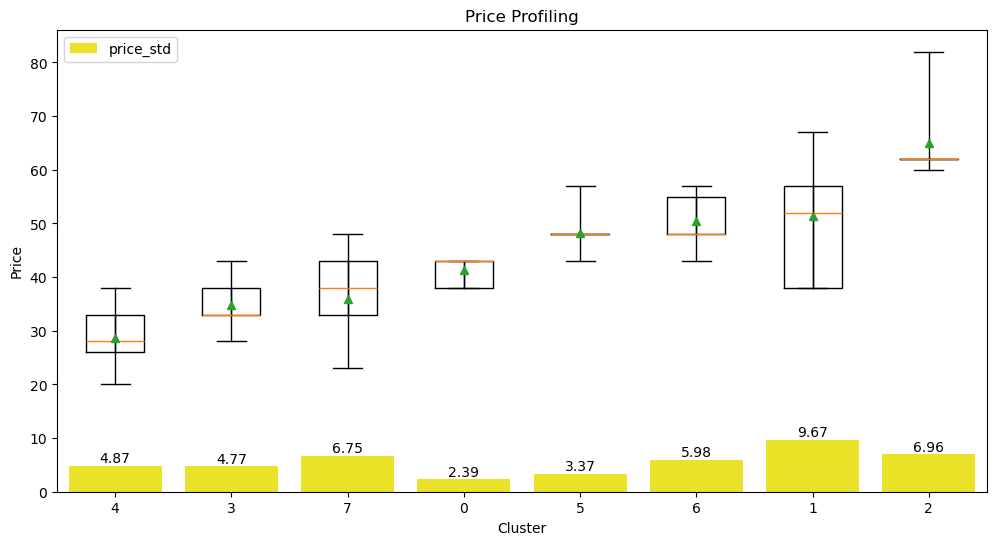

In [6]:
profiles = profiles.sort_values(by = "avg_price")
fig, ax = plt.subplots(figsize=(12, 6))
bxp_data = []
for _, row in profiles.iterrows():
    bxp_data.append({
        "label": str(row["pred"]),
        "mean": row["avg_price"],
        "q1": row["q1"],
        "med": row["median_price"],
        "q3": row["q3"],
        "whislo": row["lo"],
        "whishi": row["hi"],
        "fliers": []  # no raw data
    })
ax.bxp(bxp_data, showfliers=False, showmeans=True)
ax.bar(x = range(1, len(profiles)+1), height = profiles["price_std"], label = "price_std", color = "#E9E229")
plt.bar_label(ax.containers[0], fmt="%.2f")
ax.set_xlabel("Cluster")
ax.set_ylabel("Price")
plt.legend()
plt.title("Price Profiling")
plt.show()

### Cluster size (events + sessions)

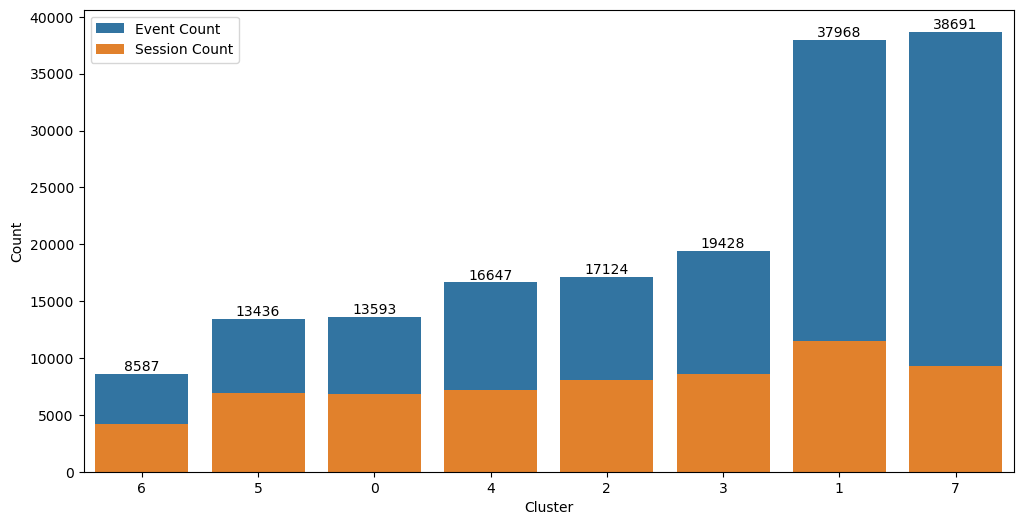

In [7]:
fig, ax = plt.subplots(figsize=(12, 6))
profiles.sort_values(by="cluster_size_events", inplace=True)
sns.barplot(profiles, x = profiles["pred"].astype(str), y = "cluster_size_events", ax =ax, label = "Event Count")
sns.barplot(profiles, x = profiles["pred"].astype(str), y = "cluster_size_sessions", ax =ax, label = "Session Count")
plt.bar_label(ax.containers[0])
plt.legend()
plt.xlabel("Cluster")
plt.ylabel("Count")
plt.show()

### Color and model diversity

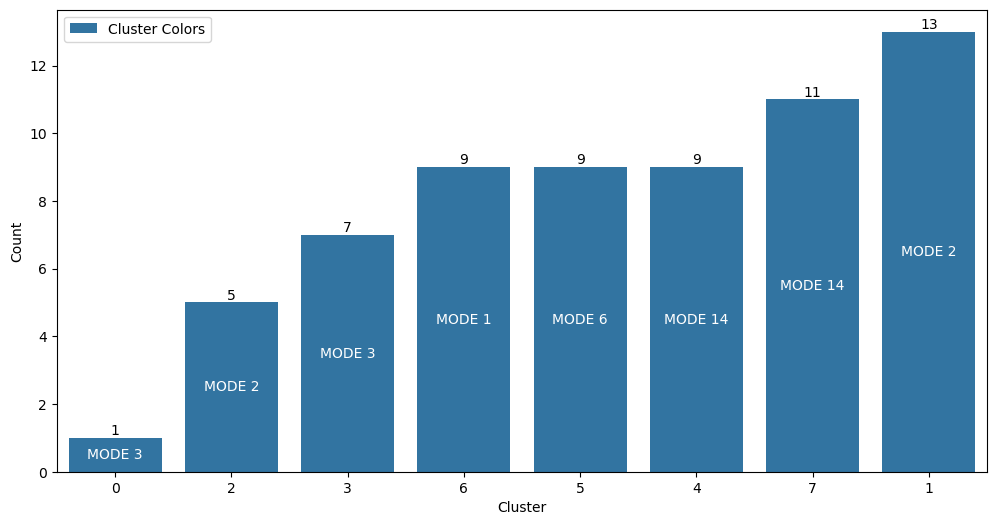

In [8]:
fig, ax = plt.subplots(figsize=(12, 6))
profiles.sort_values(by="colour_diversity", inplace=True)
sns.barplot(x = profiles["pred"].astype(str), y = profiles["colour_diversity"], label = "Cluster Colors", ax=ax)
plt.bar_label(ax.containers[0])
for i, p in enumerate(ax.patches):
    value = p.get_height()
    ax.text(p.get_x() + p.get_width() / 2, p.get_height() / 2, "MODE " + str(profiles["top_colour"][i]), ha="center", va="center", color="white")
plt.legend()
plt.xlabel("Cluster")
plt.ylabel("Count")
plt.show()

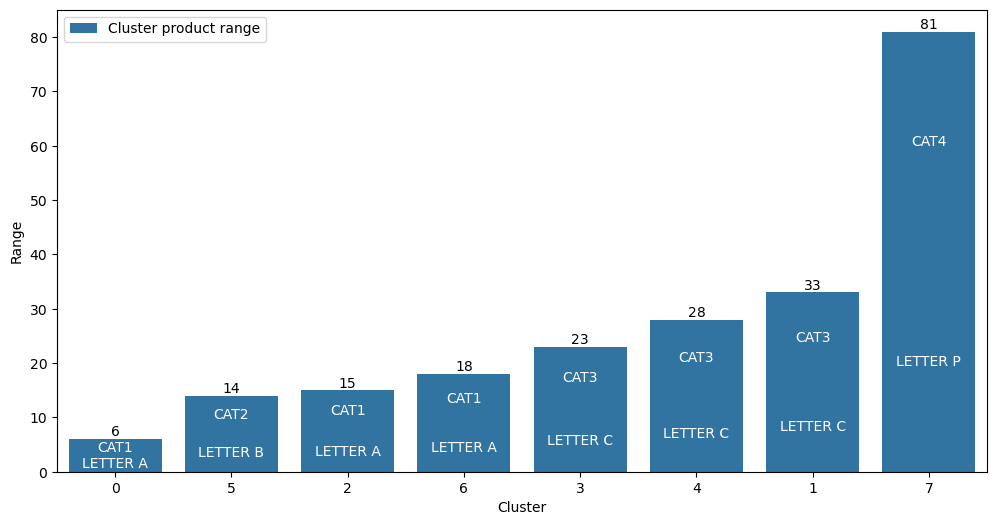

In [9]:
fig, ax = plt.subplots(figsize=(12, 6))
profiles.sort_values(by="model_diversity", inplace=True)
sns.barplot(x = profiles["pred"].astype(str), y = profiles["model_diversity"], label = "Cluster product range", ax=ax)
plt.bar_label(ax.containers[0])
for i, p in enumerate(ax.patches):
    value = p.get_height()
    ax.text(p.get_x() + p.get_width() / 2, p.get_height() - p.get_height() / 4, "CAT" + str(profiles["top_category"][i]), ha="center", va="center", color="white")
    ax.text(p.get_x() + p.get_width() / 2, p.get_height() / 4, "LETTER " + str(profiles["top_model_letter"][i]), ha="center", va="center", color="white")
plt.legend()
plt.xlabel("Cluster")
plt.ylabel("Range")
plt.show()

### Photography preference and page depth

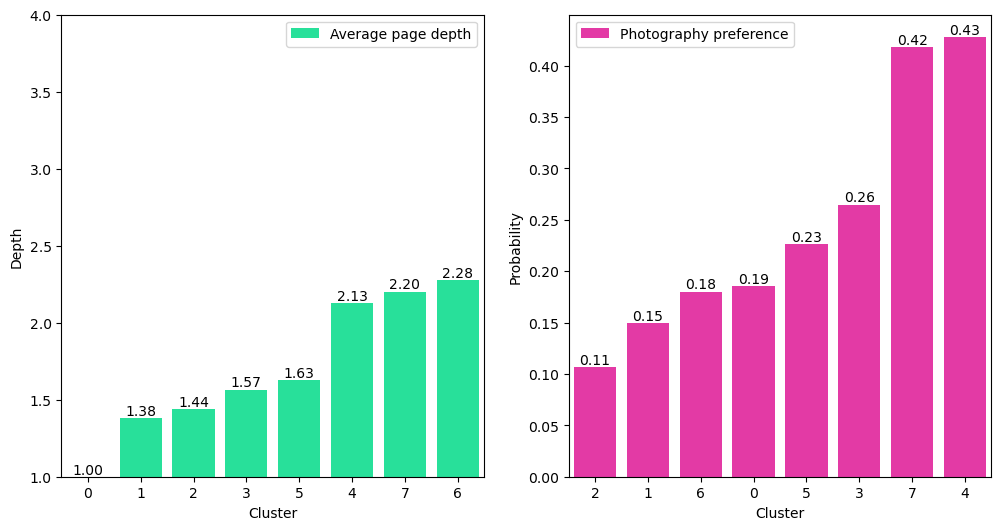

In [10]:
fig =  plt.figure(figsize=(12, 6))
cols = ["avg_page_depth", "photography_probability"]
labels = [ "Average page depth", "Photography preference"]
ylabels = ["Depth","Probability"]
colors = [ "#09FFA1",  "#FF1EAC"]
for i, col in enumerate(cols):
    ax = plt.subplot(1, 2, i+1)
    profiles.sort_values(by=col, inplace=True)
    sns.barplot(x = profiles["pred"].astype(str), y = profiles[col], label = labels[i], ax=ax, color = colors[i])
    plt.bar_label(ax.containers[0], fmt = "%.2f")
    plt.legend()
    if i == 0:
        plt.ylim((1, 4))
    plt.xlabel("Cluster")
    plt.ylabel(ylabels[i])
plt.show()


### Top categories

In [11]:
top_categories = top_categories.toPandas()

,main_category,pred,count
0,1,0,13593
1,4,7,38343
2,2,3,1
3,1,2,16722
4,1,3,19427
5,3,5,13436
6,2,1,37966
7,2,4,93
8,3,6,8587
9,3,4,16554


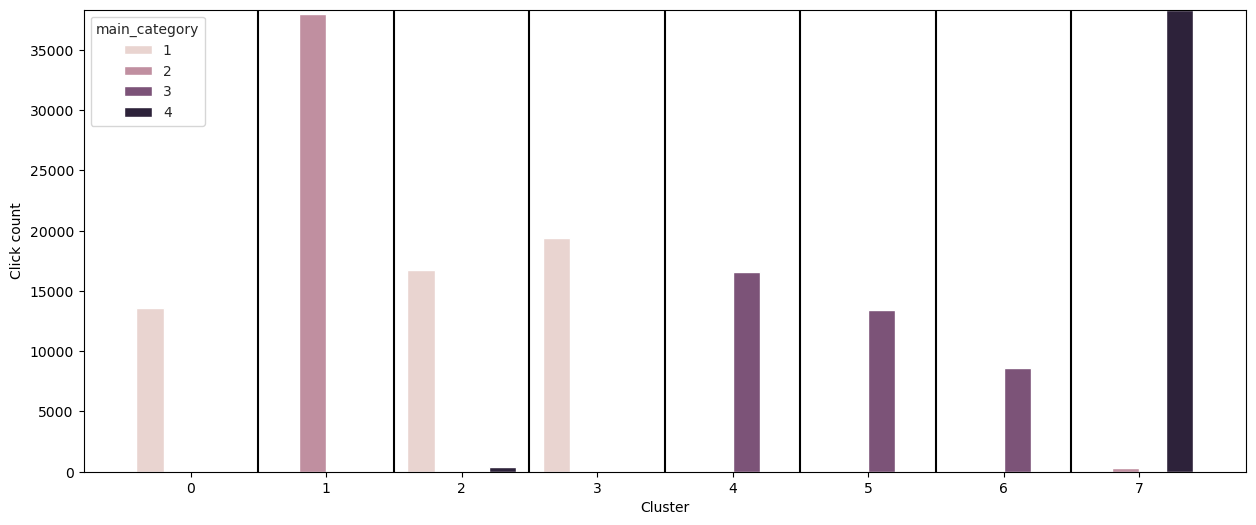

In [12]:
fig = plt.figure(figsize=(15, 6))
import numpy as np
display(top_categories)
ax = plt.axes()
sns.set_style("whitegrid")
sns.barplot(top_categories, x = "pred", y = "count", hue = "main_category", ax =ax)
plt.vlines(np.arange(0.5, 7.5), ymin= 0, ymax=top_categories["count"].max(), colors = "black")
plt.ylim(0, top_categories["count"].max())
plt.ylabel("Click count")
plt.xlabel("Cluster")
plt.show()

### Top 5 cluster products

In [13]:
top_products = top_products.toPandas()

,pred,model,count,rank
0,0,A2,3013,1
1,0,A4,2522,2
2,0,A5,2354,3
3,0,A10,2280,4
4,0,A6,1802,5
5,1,B4,3579,1
6,1,B10,2566,2
7,1,B13,1919,3
8,1,B24,1879,4
9,1,B1,1552,5


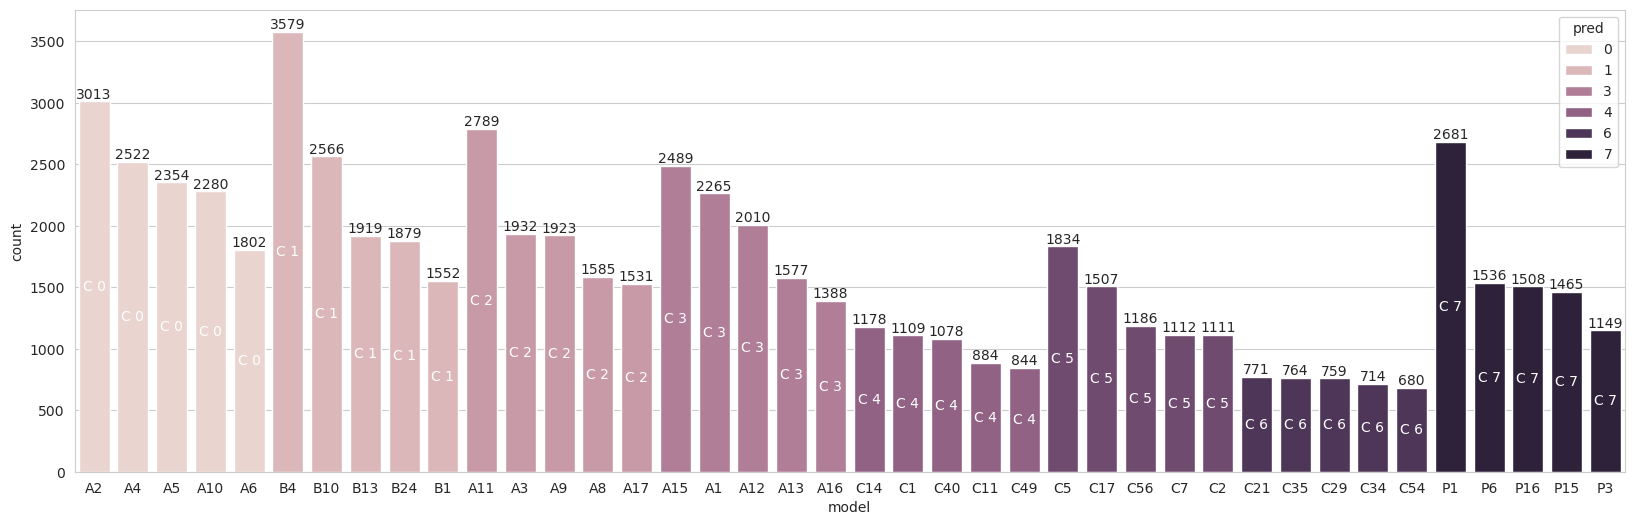

In [14]:
display(top_products)
fig = plt.figure(figsize=(20, 6))
sns.set_style("whitegrid")
ax = plt.axes()
sns.barplot(top_products, x = "model", y = "count", hue = "pred", ax =ax)
for c in ax.containers:
    plt.bar_label(c)
for i, p in enumerate(ax.patches):
    value = p.get_height()
    if i < len(top_products):
        ax.text(p.get_x() + p.get_width() / 2, p.get_height() / 2, "C " + str(top_products["pred"][i]), ha="center", va="center", color="white")
plt.show()

### Top 5 Colors

In [15]:
top_colors = top_colors.toPandas()

,colour,pred,count,rank
0,3,0,13593,1
1,2,1,9817,1
2,12,1,5460,2
3,9,1,4358,3
4,6,1,4015,4
5,10,1,3579,5
6,3,2,9575,1
7,2,2,3248,2
8,6,2,1889,3
9,1,2,1388,4


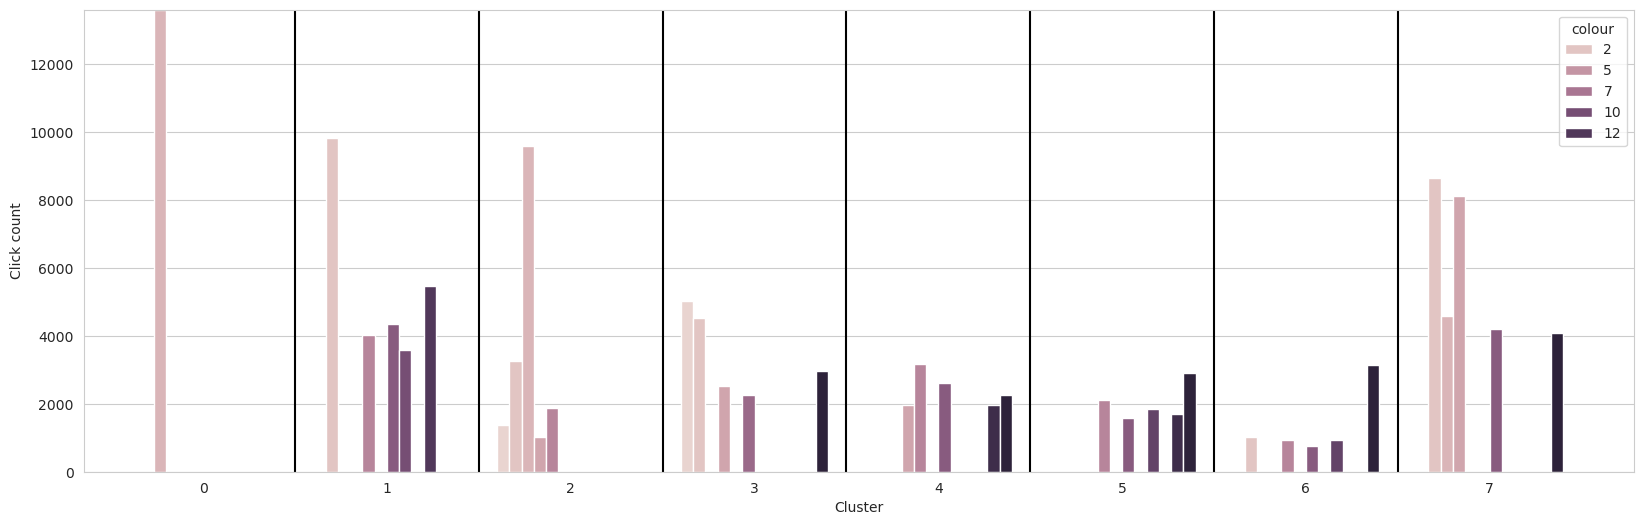

In [16]:
display(top_colors)
sns.set_style("whitegrid")
top_colors.sort_values("pred", inplace = True)
top_colors["pred"] = top_colors["pred"].astype(str)
fig = plt.figure(figsize=(20, 6))
ax = plt.axes()
sns.barplot(top_colors, x = "pred", y = "count", hue = "colour", ax =ax)
plt.vlines(np.arange(0.5, 7.5), ymin= 0, ymax=top_colors["count"].max(), colors = "black")
plt.xlabel("Cluster")
plt.ylabel("Click count")
plt.ylim(0, top_colors["count"].max())
plt.show()

### Dumping cluster profiles

In [17]:
display(profiles[["pred", "product_set", "category_set", "color_set"]])

,pred,product_set,category_set,color_set
2,2,"[P10, A3, A27, A14, A31, A22, A8, A37, A11, A2...","[1, 4]","[1, 2, 3, 4, 6]"
1,1,"[B32, B14, B15, B2, B9, B5, B8, B3, B22, P22, ...","[2, 4]","[1, 2, 3, 4, 6, 7, 8, 9, 10, 11, 12, 13, 14]"
6,6,"[C23, C36, C22, C45, C27, C54, C29, C20, C39, ...",[3],"[2, 3, 6, 7, 9, 11, 12, 13, 14]"
0,0,"[A5, A2, A6, A7, A10, A4]",[1],[3]
5,5,"[C12, C7, C58, C2, C5, C59, C17, C56, C9, C4, ...",[3],"[2, 4, 5, 6, 9, 11, 12, 13, 14]"
3,3,"[A24, A1, A28, A15, A25, A34, A42, A23, A35, A...","[1, 2]","[1, 2, 4, 6, 8, 12, 14]"
7,7,"[P30, P2, P45, P71, P12, P77, P29, P11, P23, P...","[2, 4]","[1, 2, 3, 4, 5, 6, 7, 9, 11, 12, 14]"
4,4,"[C57, C6, C47, C11, C14, C25, C53, C16, C3, C2...","[2, 3]","[2, 4, 5, 6, 7, 9, 12, 13, 14]"


In [18]:
profiles.to_csv("profile_data.csv")